# Comparación: Regresión Logística vs SVM (Lineal y RBF)
Dataset: `diabetes_prediction_dataset.csv`  
Objetivo: comparar modelos de **clasificación** para predecir `diabetes` (0/1) siguiendo los siguientes bloques:
1) Preparación
2) Regresión logística
3) SVM lineal
4) SVM con kernel RBF



> Nota: los cálculos pueden ralentizarse, el Dataset está en el límite de empezar a ser difícil de manejar

## 0. Importaciones

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from sklearn.linear_model import LogisticRegression
from sklearn.tree import export_graphviz
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score,roc_curve, roc_auc_score, precision_score, recall_score, f1_score, classification_report, accuracy_score

## 1) Bloque 1 — Preparación: carga y exploración
Objetivo del bloque: dejar el dataset listo para entrenar modelos.

- Detectamos columnas numéricas y categóricas.
- Hacemos `train_test_split` con `stratify=y`.
- **Escalamos** numéricas (imprescindible para SVM).
- Codificamos categóricas con One-Hot.


In [2]:
df_diabetes = pd.read_csv('diabetes_prediction_dataset.csv')
df_diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
# PREPARACIÓN DE DATOS
print("=" * 70)
print("PREPARACIÓN DE DATOS")
print("=" * 70)

df_diabetes = pd.get_dummies(df_diabetes,dtype=int)

# 1. Separar X e y
X = df_diabetes.drop(columns=['diabetes'])
y = df_diabetes['diabetes'].to_frame()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# 2. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 3. Escalar con StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDatos escalados correctamente")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

PREPARACIÓN DE DATOS

X shape: (100000, 15)
y shape: (100000, 1)

X_train shape: (80000, 15)
X_test shape: (20000, 15)

Datos escalados correctamente
X_train_scaled shape: (80000, 15)
X_test_scaled shape: (20000, 15)


### Funciones auxiliares de evaluación
Calculamos métricas estándar y pintamos:
- No olvidar Matriz de confusión

## 2) Bloque 2 — Regresión Logística
Entrenamos una regresión logística y evaluamos.



/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC: 0.9626
Umbral óptimo: 0.0729
FPR óptimo:    0.1238
TPR óptimo:    0.9024


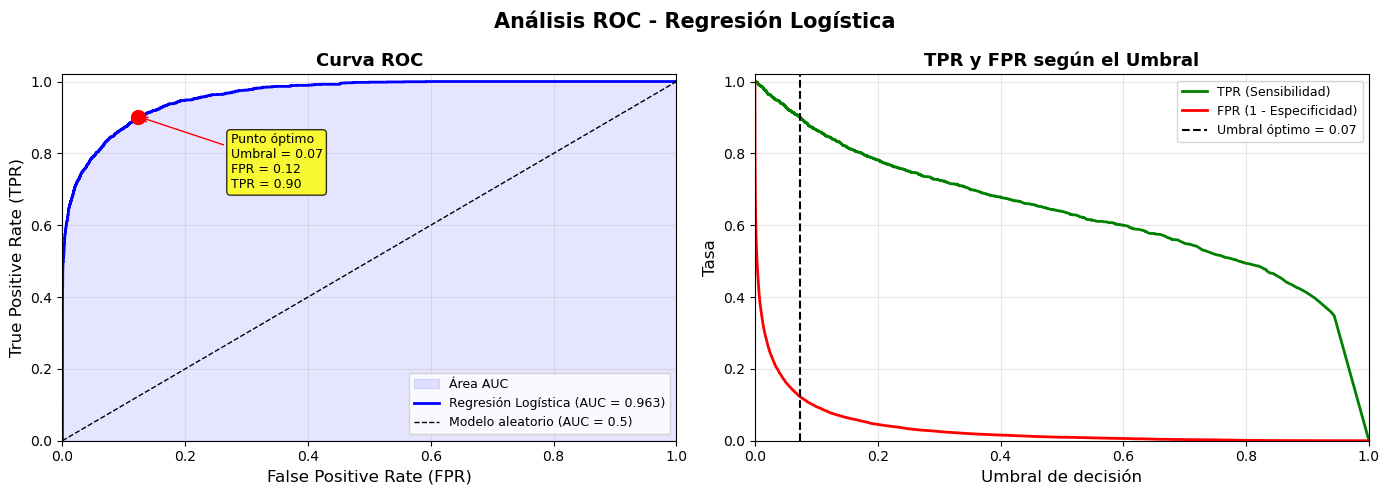

In [19]:
# ============================================================
# Curva ROC mejorada - Regresión Logística
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Entrenar modelo
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# 2. Probabilidades y curva ROC
y_prob = modelo.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# 3. Calcular punto óptimo (máxima distancia a la diagonal)
distancias = np.sqrt(fpr**2 + (1 - tpr)**2)
idx_optimo = np.argmin(distancias)
umbral_optimo = thresholds[idx_optimo]

print(f"AUC: {auc:.4f}")
print(f"Umbral óptimo: {umbral_optimo:.4f}")
print(f"FPR óptimo:    {fpr[idx_optimo]:.4f}")
print(f"TPR óptimo:    {tpr[idx_optimo]:.4f}")

# 4. Gráfica mejorada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico izquierdo: Curva ROC ─────────────────────────────
ax1 = axes[0]

# Área bajo la curva sombreada
ax1.fill_between(fpr, tpr, alpha=0.1, color="blue", label="Área AUC")

# Curva ROC
ax1.plot(fpr, tpr, color="blue", linewidth=2,
         label=f"Regresión Logística (AUC = {auc:.3f})")

# Línea diagonal (modelo aleatorio)
ax1.plot([0, 1], [0, 1], "k--", linewidth=1, label="Modelo aleatorio (AUC = 0.5)")

# Punto óptimo
ax1.scatter(fpr[idx_optimo], tpr[idx_optimo],
            color="red", s=100, zorder=5)
ax1.annotate(
    f"Punto óptimo\nUmbral = {umbral_optimo:.2f}\nFPR = {fpr[idx_optimo]:.2f}\nTPR = {tpr[idx_optimo]:.2f}",
    xy=(fpr[idx_optimo], tpr[idx_optimo]),
    xytext=(fpr[idx_optimo] + 0.15, tpr[idx_optimo] - 0.2),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8)
)

ax1.set_xlabel("False Positive Rate (FPR)", fontsize=12)
ax1.set_ylabel("True Positive Rate (TPR)", fontsize=12)
ax1.set_title("Curva ROC", fontsize=13, fontweight="bold")
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])

# ── Gráfico derecho: Umbral vs TPR/FPR ──────────────────────
ax2 = axes[1]

# thresholds from roc_curve typically include +inf at index 0. To avoid plotting inf
# and to ensure x and y have the same length, remove that first element.
# Use the same slice for thresholds, tpr and fpr.
if len(thresholds) > 0 and np.isinf(thresholds[0]):
    thr = thresholds[1:]
    tpr_plot = tpr[1:]
    fpr_plot = fpr[1:]
else:
    thr = thresholds
    tpr_plot = tpr
    fpr_plot = fpr

ax2.plot(thr, tpr_plot, color="green",  linewidth=2, label="TPR (Sensibilidad)")
ax2.plot(thr, fpr_plot, color="red",    linewidth=2, label="FPR (1 - Especificidad)")

# Línea vertical en el umbral óptimo
# If umbral_optimo was at index 0 (inf) it won't be in thr; use value directly if finite.
if np.isfinite(umbral_optimo):
    ax2.axvline(x=umbral_optimo, color="black", linestyle="--", linewidth=1.5,
                label=f"Umbral óptimo = {umbral_optimo:.2f}")

ax2.set_xlabel("Umbral de decisión", fontsize=12)
ax2.set_ylabel("Tasa", fontsize=12)
ax2.set_title("TPR y FPR según el Umbral", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

plt.suptitle("Análisis ROC - Regresión Logística", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("curva_roc.png", dpi=150, bbox_inches="tight")
plt.show()

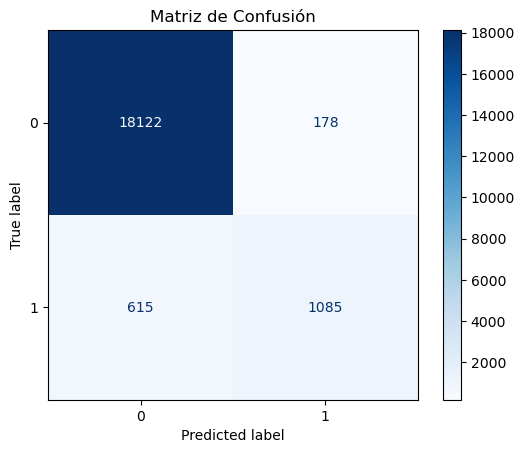

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

In [18]:


print("="*50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"R2 Score  : {r2_score(y_test, y_pred):.4f}")
print(f"AUC       : {auc:.4f}")
print("="*50)

# Reporte completo
print(classification_report(y_test, y_pred))

Accuracy  : 0.9604
Precision : 0.8591
Recall    : 0.6382
F1 Score  : 0.7324
R2 Score  : 0.4902
AUC       : 0.9626
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



## 3) Bloque 3 — SVM lineal
Entrenamos una SVM con kernel lineal.



In [5]:

print("=" * 70)
print("BÚSQUEDA DE MEJORES HIPERPARÁMETROS: Lineal")
print("=" * 70)

# Parámetros a probar
valores_C = [0.1, 1, 4, 7, 10]
valores_gamma = ['scale', 'auto', 0.001, 0.01, 0.1]

# Diccionarios para almacenar mejores modelos
mejores_modelos = {
    'lineal': {'accuracy': 0, 'config': None, 'model': None},
}

# KERNEL RBF
print("\n" + "-" * 70)
print("ENTRENANDO: KERNEL LINEAR")
print("-" * 70)

for C in valores_C:
    for gamma in valores_gamma:
        svm_lineal = SVC(kernel="linear", C=C, gamma=gamma)
        svm_lineal.fit(X_train_scaled, y_train)

        pred_lineal = svm_lineal.predict(X_test_scaled)
        acc_lineal = accuracy_score(y_test, pred_lineal)

        print(f"  C={C:4.1f} | gamma={str(gamma):8} | Accuracy: {acc_lineal:.4f}", end="")

        if acc_lineal > mejores_modelos['lineal']['accuracy']:
            mejores_modelos['lineal']['accuracy'] = acc_lineal
            mejores_modelos['lineal']['config'] = {'C': C, 'gamma': gamma}
            mejores_modelos['lineal']['model'] = svm_lineal
            print(" ⭐ (NUEVO MEJOR)")
        else:
            print()

# COMPARACIÓN FINAL
print("\n" + "=" * 70)
print("RESUMEN DE MEJORES MODELOS")
print("=" * 70)

print(f"\n🔹 LINEAL:")
print(f"   Accuracy: {mejores_modelos['lineal']['accuracy']:.4f}")
print(f"   Config:   {mejores_modelos['lineal']['config']}")

# Determinar el ganador

mejor_kernel = 'lineal'
print(f"\n🏆 GANADOR: KERNEL LINEAL")


print(f"   Accuracy: {mejores_modelos[mejor_kernel]['accuracy']:.4f}")
print(f"   Config: {mejores_modelos[mejor_kernel]['config']}")

BÚSQUEDA DE MEJORES HIPERPARÁMETROS: Lineal

----------------------------------------------------------------------
ENTRENANDO: KERNEL LINEAR
----------------------------------------------------------------------


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  C= 0.1 | gamma=scale    | Accuracy: 0.9609 ⭐ (NUEVO MEJOR)


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  C= 0.1 | gamma=auto     | Accuracy: 0.9609


...

/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  C=10.0 | gamma=0.01     | Accuracy: 0.9607


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  C=10.0 | gamma=0.1      | Accuracy: 0.9607

RESUMEN DE MEJORES MODELOS

🔹 LINEAR:


KeyError: 'linear'

In [6]:
pred_linear = svm_lineal.predict(X_test_scaled)

print("=== SVM LINEAL ===")
print("Accuracy:", accuracy_score(y_test, pred_linear))
print(confusion_matrix(y_test, pred_linear))
print(classification_report(y_test, pred_linear))

=== SVM LINEAL ===
Accuracy: 0.96075
[[18190   110]
 [  675  1025]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18300
           1       0.90      0.60      0.72      1700

    accuracy                           0.96     20000
   macro avg       0.93      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



## 4) Bloque 4 — SVM con kernel RBF
Entrenamos una SVM con kernel gaussiano (RBF).



In [8]:
# BÚSQUEDA EXHAUSTIVA: POLINOMIAL vs RBF
print("=" * 70)
print("BÚSQUEDA DE MEJORES HIPERPARÁMETROS: POLY vs RBF")
print("=" * 70)

# Parámetros a probar
valores_C = [0.1, 1, 4, 7, 10]
valores_gamma = ['scale', 'auto', 0.001, 0.01, 0.1]
valores_degree = [2, 3, 4, 5]
valores_coef0 = [1, 4, 5, 8, 10]

# Diccionarios para almacenar mejores modelos
mejores_modelos = {
    'poly': {'accuracy': 0, 'config': None, 'model': None},
    'rbf': {'accuracy': 0, 'config': None, 'model': None}
}

# KERNEL RBF
print("\n" + "-" * 70)
print("ENTRENANDO: KERNEL RBF")
print("-" * 70)

for C in valores_C:
    for gamma in valores_gamma:
        svm_rbf = SVC(kernel="rbf", C=C, gamma=gamma)
        svm_rbf.fit(X_train_scaled, y_train)
        
        pred_rbf = svm_rbf.predict(X_test_scaled)
        acc_rbf = accuracy_score(y_test, pred_rbf)
        
        print(f"  C={C:4.1f} | gamma={str(gamma):8} | Accuracy: {acc_rbf:.4f}", end="")
        
        if acc_rbf > mejores_modelos['rbf']['accuracy']:
            mejores_modelos['rbf']['accuracy'] = acc_rbf
            mejores_modelos['rbf']['config'] = {'C': C, 'gamma': gamma}
            mejores_modelos['rbf']['model'] = svm_rbf
            print(" ⭐ (NUEVO MEJOR)")
        else:
            print()

# COMPARACIÓN FINAL
print("\n" + "=" * 70)
print("RESUMEN DE MEJORES MODELOS")
print("=" * 70)

print(f"\n🔹 POLINOMIAL:")
print(f"   Accuracy: {mejores_modelos['poly']['accuracy']:.4f}")
print(f"   Config:   {mejores_modelos['poly']['config']}")

print(f"\n🔹 RBF:")
print(f"   Accuracy: {mejores_modelos['rbf']['accuracy']:.4f}")
print(f"   Config:   {mejores_modelos['rbf']['config']}")

# Determinar el ganador
if mejores_modelos['poly']['accuracy'] > mejores_modelos['rbf']['accuracy']:
    mejor_kernel = 'poly'
    print(f"\n🏆 GANADOR: KERNEL POLINOMIAL")
else:
    mejor_kernel = 'rbf'
    print(f"\n🏆 GANADOR: KERNEL RBF")

print(f"   Accuracy: {mejores_modelos[mejor_kernel]['accuracy']:.4f}")
print(f"   Config: {mejores_modelos[mejor_kernel]['config']}")

BÚSQUEDA DE MEJORES HIPERPARÁMETROS: POLY vs RBF

----------------------------------------------------------------------
ENTRENANDO: KERNEL RBF
----------------------------------------------------------------------


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  C= 0.1 | gamma=scale    | Accuracy: 0.9619 ⭐ (NUEVO MEJOR)


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  C= 0.1 | gamma=auto     | Accuracy: 0.9619


...

  C=10.0 | gamma=0.001    | Accuracy: 0.9623


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  C=10.0 | gamma=0.01     | Accuracy: 0.9631


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  C=10.0 | gamma=0.1      | Accuracy: 0.9645 ⭐ (NUEVO MEJOR)

RESUMEN DE MEJORES MODELOS

🔹 POLINOMIAL:
   Accuracy: 0.0000
   Config:   None

🔹 RBF:
   Accuracy: 0.9645
   Config:   {'C': 10, 'gamma': 0.1}

🏆 GANADOR: KERNEL RBF
   Accuracy: 0.9645
   Config: {'C': 10, 'gamma': 0.1}


In [9]:
pred_rbf = svm_rbf.predict(X_test_scaled)

print("=== SVM RBF ===")
print("Accuracy:", accuracy_score(y_test, pred_rbf))
print(confusion_matrix(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))

=== SVM RBF ===
Accuracy: 0.96445
[[18255    45]
 [  666  1034]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
           1       0.96      0.61      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.96      0.80      0.86     20000
weighted avg       0.96      0.96      0.96     20000



## 5) Resumen
Comparamos resultados en una tabla.

### Preguntas
1. ¿Qué modelo tiene mejor **recall** para la clase positiva (`diabetes=1`)?
2. En un contexto médico, ¿qué error es más grave: **FP** o **FN**? Explica.
3. ¿Qué modelo escogerías si tu prioridad es **interpretabilidad**? ¿y si tu prioridad es **rendimiento**?
4. ¿Por qué el escalado afecta más a SVM que a la logística?
5. Si el dataset está desbalanceado, ¿qué métrica sería más fiable que accuracy?

In [ ]:
# ============================================================
# Cálculo y visualización de la curva ROC y del AUC
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
# Para variar la curva ROC en regresión logística debes modificar:

# C (regularización)

# penalty (consultar documentación oficial)

# Datos de entrenamiento
# ============================================================

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# 1️. Entrenamos modelo (si no lo estuviera ya)
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# 2️. Obtenemos probabilidades de la clase positiva
y_prob = modelo.predict_proba(X_test)[:, 1]

# 3️. Calculamos puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 4️. Calculamos AUC
auc = roc_auc_score(y_test, y_prob)

print(f"AUC del modelo: {auc:.4f}")

# 5️. Representación gráfica
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")  # Línea diagonal (modelo aleatorio)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()
